Original data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Mean after scaling (~0): [-0. -0. -0. -0.]
Std after scaling (~1): [1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance matrix:
 [[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Eigenvalues (sorted): [2.938 0.92  0.148 0.021]
Explained variance ratio: [0.73  0.229 0.037 0.005]
Cumulative variance (first 2 components): 0.958

Transformed data shape (from scratch): (150, 2)

PCA USING SCIKIT-LEARN

Explained variance ratio: [0.73  0.229]
Cumulative variance (first 2 components): 0.958
Transformed data shape (sklearn): (150, 2)

Plot saved as pca_iris_result.png

Sanity check passed: scratch implementation matches scikit-learn.


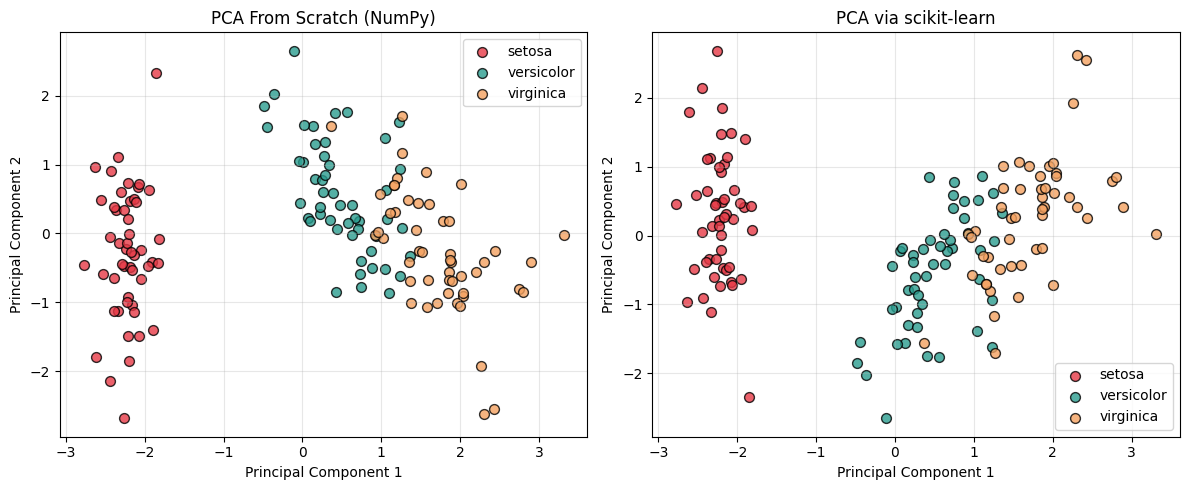

In [1]:
"""
PCA Laboratory Demonstration
============================
This script demonstrates Principal Component Analysis (PCA) in two ways:
  1. Implemented from scratch using NumPy (to understand the math)
  2. Using scikit-learn's PCA class (the practical, production way)

Dataset: The classic Iris dataset (4 features, 150 samples, 3 classes)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------------------------------
iris = load_iris()
X = iris.data                # shape (150, 4) -> 4 features
y = iris.target              # class labels (0, 1, 2)
feature_names = iris.feature_names

print("Original data shape:", X.shape)
print("Feature names:", feature_names)

# -----------------------------------------------------------------------
# STEP 2: Standardize the data (mean = 0, std = 1)
# PCA is affected by scale, so features must be standardized first.
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std after scaling (~1):", np.round(X_scaled.std(axis=0), 3))

# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH (using NumPy)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# 1. Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance matrix:\n", np.round(cov_matrix, 3))

# 2. Compute eigenvalues and eigenvectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 3. Sort eigenvalues (and corresponding eigenvectors) in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues (sorted):", np.round(eigen_values, 3))

# 4. Compute explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# 5. Select top k eigenvectors (k=2) to form the projection matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# 6. Project the standardized data onto the new subspace
X_pca_scratch = X_scaled.dot(projection_matrix)
print("\nTransformed data shape (from scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN (practical approach)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# STEP 4: Visualize the result
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]
target_names = iris.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_iris_result.png", dpi=150)
print("\nPlot saved as pca_iris_result.png")

# -----------------------------------------------------------------------
# STEP 5: Sanity check - both methods should give (near) identical variance
# -----------------------------------------------------------------------
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")

Original data shape: (569, 30)
Feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Mean after scaling (~0):
[-0. -0. -0. -0.  0. -0. -0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0. -0.
 -0. -0. -0.  0. -0.  0. -0. -0.  0. -0. -0.  0.]

Std after scaling (~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance Matrix Shape: (30, 30)

Eigenvalues:
[1.3305e+01 5.7010e+00 2.8230e+00 1.9840e+00 1.6520e+00 1.2090e+

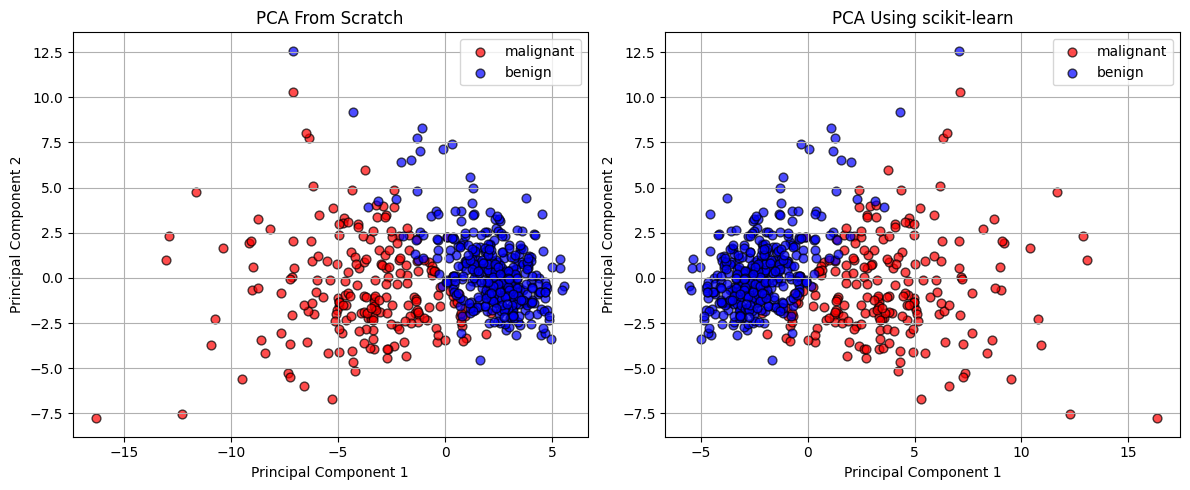


Plot saved as 'pca_breast_cancer_result.png'

Sanity check passed!
Scratch implementation matches scikit-learn.


In [3]:
"""
PCA Laboratory Demonstration
============================
This script demonstrates Principal Component Analysis (PCA) in two ways:
1. Implemented from scratch using NumPy
2. Using scikit-learn's PCA class

Dataset: Breast Cancer Wisconsin Dataset
(569 samples, 30 features, 2 classes)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------------------------------
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names

print("Original data shape:", X.shape)
print("Feature names:\n", feature_names)

# -----------------------------------------------------------------------
# STEP 2: Standardize the data
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):")
print(np.round(X_scaled.mean(axis=0), 3))

print("\nStd after scaling (~1):")
print(np.round(X_scaled.std(axis=0), 3))

# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# Covariance matrix
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance Matrix Shape:", cov_matrix.shape)

# Eigenvalues and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues:")
print(np.round(eigen_values, 3))

# Explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("\nExplained Variance Ratio:")
print(np.round(explained_variance_ratio, 3))

print("Cumulative Variance (First 2 Components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# Projection matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# Transform data
X_pca_scratch = X_scaled.dot(projection_matrix)

print("\nTransformed Data Shape (Scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(np.round(pca.explained_variance_ratio_, 3))

print("Cumulative Variance:",
      np.round(np.sum(pca.explained_variance_ratio_), 3))

print("Transformed Data Shape (sklearn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# STEP 4: Visualization
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["red", "blue"]
target_names = cancer.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch", "PCA Using scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0],
            data[y == i, 1],
            label=target_name,
            color=colors[i],
            edgecolor="black",
            alpha=0.7,
            s=40,
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("pca_breast_cancer_result.png", dpi=300)
plt.show()

print("\nPlot saved as 'pca_breast_cancer_result.png'")

# -----------------------------------------------------------------------
# STEP 5: Verify Results
# -----------------------------------------------------------------------
assert np.allclose(
    np.sort(explained_variance_ratio[:2]),
    np.sort(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"

print("\nSanity check passed!")
print("Scratch implementation matches scikit-learn.")